In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stat
import inspect

!pip install iminuit
from iminuit import Minuit
from iminuit.cost import LeastSquares

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 7.0 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
data = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/cleo_fit_data.csv")
data2 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/babar_fit_data.csv")
data3 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/besiii_1_fit_data.csv")
data4 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/besiii_2_fit_data.csv")
data5 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/besiii_3_fit_data.csv")

In [ ]:
best_params3 = {'c11': -0.06602074655646047,
                'c12': -0.2793086776223737,
                'c22': -0.049856475100191915,
                'p10_1': -0.9664945823436839,
                'p20_1': 2.960327615008674,
                'p10_2': 2.2349233187322435,
                'p20_2': -4.6320271257722405,
                'p10_3': -1.5472957400612406,
                'p20_3': 4.847777851499343,
                'p10_4': 0.11075704375121882,
                'p20_4': 1.481340532567896,
                'p10_5': -0.17756367841800047,
                'p20_5': 1.6948389972458224}

#masses [GeV]
m_K = 0.493677
m_pi_pm = 0.13957039
m_pi = 0.134977
m_eta = 0.547862
m_chic1 = 3.5107
m_Ds = 1.96835
m_etac = 2.9841

datasets = [
    {'x': data['M'].to_numpy(), 'y': data['I'].to_numpy(), 'y_err': data['dI'].to_numpy(), 'M': m_chic1},
    {'x': data2['M'].to_numpy(), 'y': data2['I'].to_numpy(), 'y_err': data2['dI'].to_numpy(), 'M': m_etac},
    {'x': data3['M'].to_numpy(), 'y': data3['I'].to_numpy(), 'y_err': data3['dI'].to_numpy(), 'M': m_chic1},
    {'x': data4['M'].to_numpy(), 'y': data4['I'].to_numpy(), 'y_err': data4['dI'].to_numpy(), 'M': m_Ds},
    {'x': data5['M'].to_numpy(), 'y': data5['I'].to_numpy(), 'y_err': data5['dI'].to_numpy(), 'M': m_Ds}
]

In [ ]:
def sqrt_lambda(x, y, z):
  lmbda = x ** 2 + y ** 2 + z ** 2 - 2 * x * y - 2 * x * z - 2 * y * z
  return np.sqrt(lmbda + 0j)

def k1(s, m_pi, m_eta):
  s1 = (m_pi + m_eta) ** 2
  mu = np.sqrt(m_pi * m_eta) / (m_pi + m_eta)
  return np.where(s >= s1, mu * np.sqrt(s - s1 + 0j), mu * 1j * np.sqrt(s1 - s + 0j))

def k2(s, m_K):
  s2 = 4 * m_K ** 2
  return np.where(s >= s2, (1 / 2)* np.sqrt(s - s2 + 0j), (1 / 2) * 1j * np.sqrt(s2 - s + 0j))

def phase_space(s, M, m_s=m_pi, m_pi=m_pi, m_eta=m_eta):
  p = sqrt_lambda(s, M ** 2, m_s ** 2) / (2 * M)
  q = sqrt_lambda(s, m_pi ** 2, m_eta ** 2) / (2 * np.sqrt(s))
  return M * np.real(p * q)

def P(s, p10, p20):
  return p10, p20

def T(s, c11, c12, c22, m_pi=m_pi, m_eta=m_eta, m_K=m_K):
  num1 = c22 - 1j * k2(s, m_K)
  denom1 = (c11 - 1j * k1(s, m_pi, m_eta)) * (c22 - 1j * k2(s, m_K)) - c12 ** 2
  num2 = -c12
  denom2 = (c11 - 1j * k1(s, m_pi, m_eta)) * (c22 - 1j * k2(s, m_K)) - c12 ** 2
  return num1 / denom1, num2 / denom2

def Intensity1(E, c11, c12, c22, p10_1, p20_1):
  M = m_chic1
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_1, p20=p20_1)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity2(E, c11, c12, c22, p10_2, p20_2):
  M = m_etac
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_2, p20=p20_2)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity3(E, c11, c12, c22, p10_3, p20_3):
  M = m_chic1
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_3, p20=p20_3)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity4(E, c11, c12, c22, p10_4, p20_4):
  M = m_Ds
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_4, p20=p20_4)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

def Intensity5(E, c11, c12, c22, p10_5, p20_5):
  M = m_Ds
  s = E ** 2
  rho = phase_space(s, M=M, m_s=m_pi)
  P1, P2 = P(s, p10=p10_5, p20=p20_5)
  T1, T2 = T(s, c11=c11, c12=c12, c22=c22)
  bracket = np.abs(P1 * T1 + P2 * T2) ** 2
  return rho * bracket

ls = LeastSquares(datasets[0]['x'], datasets[0]['y'], datasets[0]['y_err'], model=Intensity1)\
    + LeastSquares(datasets[1]['x'], datasets[1]['y'], datasets[1]['y_err'], model=Intensity2)\
    + LeastSquares(datasets[2]['x'], datasets[2]['y'], datasets[2]['y_err'], model=Intensity3)\
    + LeastSquares(datasets[3]['x'], datasets[3]['y'], datasets[3]['y_err'], model=Intensity4)\
    + LeastSquares(datasets[4]['x'], datasets[4]['y'], datasets[4]['y_err'], model=Intensity5)

PART 1: TRAINING DATA GENERATION (DONE)

In [ ]:
# def pseudodataset(ydata, y_error):
#     return [np.random.normal(ydata[i], y_error[i]) for i in range(len(y_error))]

# def chisquare(yth, ydata, yerr):
#     chisq = [(yth[i] - ydata[i]) / yerr[i] for i in range(yth.size)]
#     return np.sum(np.multiply(chisq, chisq)), chisq

# nbs = 10000
# ypseudodata1 = [pseudodataset(datasets[0]['y'], datasets[0]['y_err']) for _ in range(nbs)]
# ypseudodata2 = [pseudodataset(datasets[1]['y'], datasets[1]['y_err']) for _ in range(nbs)]
# ypseudodata3 = [pseudodataset(datasets[2]['y'], datasets[2]['y_err']) for _ in range(nbs)]
# ypseudodata4 = [pseudodataset(datasets[3]['y'], datasets[3]['y_err']) for _ in range(nbs)]
# ypseudodata5 = [pseudodataset(datasets[4]['y'], datasets[4]['y_err']) for _ in range(nbs)]

In [ ]:
# param_names1 = list(inspect.signature(Intensity1).parameters.keys())[1:]
# nparams1 = len(param_names1)
# bs_results1 = {name: [] for name in param_names1}
# chisq_bs1   = []

# print(param_names1)

In [ ]:
# print(f"Running {nbs} bootstrap fits...")
# for i in range(nbs):
#     ls_bs = LeastSquares(data['M'], ypseudodata1[i], data['dI'], Intensity1)
#     m_bs = Minuit(ls_bs, best_params3['c11'], best_params3['c12'], best_params3['c22'], best_params3['p10_1'], best_params3['p20_1'])
#     m_bs.migrad()

#     for j, name in enumerate(param_names1):
#         bs_results1[name].append(m_bs.values[j])

#     yth_bs = Intensity1(data['M'], *m_bs.values)
#     c1, _ = chisquare(np.array(yth_bs), np.array(ypseudodata1[i]), data['dI'])
#     chisq_bs1.append(c1)

#     print(f'Bootstrap fit {i}')

# print("Bootstrap fits complete.")

In [ ]:
# plt.hist(bs_results1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# import pandas as pd
# from google.colab import files

# df1 = pd.DataFrame(bs_results1)
# df1.to_csv('bs_results1.csv', index=False)
# files.download('bs_results1.csv')

In [ ]:
# param_names2 = list(inspect.signature(Intensity2).parameters.keys())[1:]
# nparams2 = len(param_names2)
# bs_results2 = {name: [] for name in param_names2}
# chisq_bs2   = []

# print(f"Running {nbs} bootstrap fits...")
# for i in range(nbs):
#     ls_bs = LeastSquares(data2['M'], ypseudodata2[i], data2['dI'], Intensity2)
#     m_bs = Minuit(ls_bs, best_params3['c11'], best_params3['c12'], best_params3['c22'], best_params3['p10_2'], best_params3['p20_2'])
#     m_bs.migrad()

#     for j, name in enumerate(param_names2):
#         bs_results2[name].append(m_bs.values[j])

#     yth_bs = Intensity2(data2['M'], *m_bs.values)
#     c2, _ = chisquare(np.array(yth_bs), np.array(ypseudodata2[i]), data2['dI'])
#     chisq_bs2.append(c2)

#     print(f'Bootstrap fit {i}')

# print("Bootstrap fits complete.")

In [ ]:
# df2 = pd.DataFrame(bs_results2)
# df2.to_csv('bs_results2.csv', index=False)
# files.download('bs_results2.csv')

In [ ]:
# param_names3 = list(inspect.signature(Intensity3).parameters.keys())[1:]
# nparams3 = len(param_names3)
# bs_results3 = {name: [] for name in param_names3}
# chisq_bs3   = []

# print(f"Running {nbs} bootstrap fits...")
# for i in range(nbs):
#     ls_bs = LeastSquares(data3['M'], ypseudodata3[i], data3['dI'], Intensity3)
#     m_bs = Minuit(ls_bs, best_params3['c11'], best_params3['c12'], best_params3['c22'], best_params3['p10_3'], best_params3['p20_3'])
#     m_bs.migrad()

#     for j, name in enumerate(param_names3):
#         bs_results3[name].append(m_bs.values[j])

#     yth_bs = Intensity3(data3['M'], *m_bs.values)
#     c3, _ = chisquare(np.array(yth_bs), np.array(ypseudodata3[i]), data3['dI'])
#     chisq_bs3.append(c3)

#     print(f'Bootstrap fit {i}')

# print("Bootstrap fits complete.")

In [ ]:
# df3 = pd.DataFrame(bs_results3)
# df3.to_csv('bs_results3.csv', index=False)
# files.download('bs_results3.csv')

In [ ]:
# param_names4 = list(inspect.signature(Intensity4).parameters.keys())[1:]
# nparams4 = len(param_names4)
# bs_results4 = {name: [] for name in param_names4}
# chisq_bs4   = []

# print(f"Running {nbs} bootstrap fits...")
# for i in range(nbs):
#     ls_bs = LeastSquares(data4['M'], ypseudodata4[i], data4['dI'], Intensity4)
#     m_bs = Minuit(ls_bs, best_params3['c11'], best_params3['c12'], best_params3['c22'], best_params3['p10_4'], best_params3['p20_4'])
#     m_bs.migrad()

#     for j, name in enumerate(param_names4):
#         bs_results4[name].append(m_bs.values[j])

#     yth_bs = Intensity4(data4['M'], *m_bs.values)
#     c4, _ = chisquare(np.array(yth_bs), np.array(ypseudodata4[i]), data4['dI'])
#     chisq_bs4.append(c4)

#     print(f'Bootstrap fit {i}')

# print("Bootstrap fits complete.")

In [ ]:
# df4 = pd.DataFrame(bs_results4)
# df4.to_csv('bs_results4.csv', index=False)
# files.download('bs_results4.csv')

In [ ]:
# param_names5 = list(inspect.signature(Intensity5).parameters.keys())[1:]
# nparams5 = len(param_names5)
# bs_results5 = {name: [] for name in param_names5}
# chisq_bs5   = []

# print(f"Running {nbs} bootstrap fits...")
# for i in range(nbs):
#     ls_bs = LeastSquares(data5['M'], ypseudodata5[i], data5['dI'], Intensity5)
#     m_bs = Minuit(ls_bs, best_params3['c11'], best_params3['c12'], best_params3['c22'], best_params3['p10_5'], best_params3['p20_5'])
#     m_bs.migrad()

#     for j, name in enumerate(param_names5):
#         bs_results5[name].append(m_bs.values[j])

#     yth_bs = Intensity5(data5['M'], *m_bs.values)
#     c5, _ = chisquare(np.array(yth_bs), np.array(ypseudodata5[i]), data5['dI'])
#     chisq_bs5.append(c5)

#     print(f'Bootstrap fit {i}')

# print("Bootstrap fits complete.")

In [ ]:
# df5 = pd.DataFrame(bs_results5)
# df5.to_csv('bs_results5.csv', index=False)
# files.download('bs_results5.csv')

PART 2: DATA EXPLORATION (DONE)

In [ ]:
bs_results1 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs_results1.csv")
bs_results2 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs_results2.csv")
bs_results3 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs_results3.csv")
bs_results4 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs_results4.csv")
bs_results5 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs_results5.csv")

In [ ]:
# plt.hist(bs_results1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results1_filtered1 = bs_results1[bs_results1['c11'] > -7]
# plt.hist(bs_results1_filtered1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results1_filtered2 = bs_results1[bs_results1['c22'] > -5.25]
# plt.hist(bs_results1_filtered2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results1_filtered3 = bs_results1[bs_results1['c12'] > -6.4]
# plt.hist(bs_results1_filtered3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results1_filtered = bs_results1[(bs_results1['c12'] > -6.4) & (bs_results1['c22'] > -5.25) & (bs_results1['c11'] > -7)]
# plt.hist(bs_results1_filtered['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1_filtered['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results1_filtered['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results2['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results2_filtered1 = bs_results2[(bs_results2['c11'] > -2.1) & (bs_results2['c11'] < 0.5)]
# plt.hist(bs_results2_filtered1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results2_filtered2 = bs_results2[(bs_results2['c22'] > -2.3) & (bs_results2['c22'] < 0.1)]
# plt.hist(bs_results2_filtered2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results2['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results2_filtered3 = bs_results2[(bs_results2['c12'] > -2.2)]
# plt.hist(bs_results2_filtered3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results2_filtered = bs_results2[(bs_results2['c12'] > -2.2) & (bs_results2['c22'] > -2.3) & (bs_results2['c22'] < 0.1) & (bs_results2['c11'] > -2.1) & (bs_results2['c11'] < 0.5)]
# plt.hist(bs_results2_filtered['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results3['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results3_filtered1 = bs_results3[(bs_results3['c11'] > -0.12)]
# plt.hist(bs_results3_filtered1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results3['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results3_filtered2 = bs_results3[(bs_results3['c22'] > -0.07)]
# plt.hist(bs_results3_filtered2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results3_filtered3 = bs_results3[(bs_results3['c12'] > -0.291)]
# plt.hist(bs_results3_filtered3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results3_filtered = bs_results3[(bs_results3['c22'] > -0.07) & (bs_results3['c12'] > -0.291) & (bs_results3['c11'] > -0.12)]
# plt.hist(bs_results3_filtered['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results4['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results4_filtered1 = bs_results4[(bs_results4['c11'] > -0.5) & (bs_results4['c11'] < 0.18)]
# plt.hist(bs_results4_filtered1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results4['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results4_filtered2 = bs_results4[(bs_results4['c22'] > -0.235) & (bs_results4['c22'] < 0.05)]
# plt.hist(bs_results4_filtered2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results4['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results4_filtered3 = bs_results4[(bs_results4['c12'] > -0.3) & (bs_results4['c12'] < 0.0)]
# plt.hist(bs_results4_filtered3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results4_filtered = bs_results4[(bs_results4['c12'] > -0.3) & (bs_results4['c12'] < 0.0) & (bs_results4['c22'] > -0.235) & (bs_results4['c22'] < 0.05) & (bs_results4['c11'] > -0.5) & (bs_results4['c11'] < 0.18)]
# plt.hist(bs_results4_filtered['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results5['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results5_filtered1 = bs_results5[(bs_results5['c11'] > -145) & (bs_results5['c11'] < 0.1)]
# plt.hist(bs_results5_filtered1['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results5['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results5_filtered2 = bs_results5[(bs_results5['c22'] > -70) & (bs_results5['c22'] < 0.1)]
# plt.hist(bs_results5_filtered2['c22'], bins=100)
# plt.yscale('log')

In [ ]:
# plt.hist(bs_results5['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results5_filtered3 = bs_results5[(bs_results5['c12'] > -120) & (bs_results5['c12'] < 0.1)]
# plt.hist(bs_results5_filtered3['c12'], bins=100)
# plt.yscale('log')

In [ ]:
# bs_results5_filtered = bs_results5[(bs_results5['c12'] > -120) & (bs_results5['c12'] < 0.1) & (bs_results5['c22'] > -70) & (bs_results5['c22'] < 0.1) & (bs_results5['c11'] > -145) & (bs_results5['c11'] < 0.1)]
# plt.hist(bs_results5_filtered['c11'], bins=100)
# plt.yscale('log')

In [ ]:
# experiments = {
#     "1": {"model": Intensity1, "params": bs_results1_filtered},
#     "2": {"model": Intensity2, "params": bs_results2_filtered},
#     "3": {"model": Intensity3, "params": bs_results3_filtered},
#     "4": {"model": Intensity4, "params": bs_results4_filtered},
#     "5": {"model": Intensity5, "params": bs_results5_filtered}
# }

In [ ]:
# bs_results2_filtered.shape[0]

FINAL POST-CUT DATA PROVIDED BY inż. P. LEWICKI

In [ ]:
params1 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs1_postcut.csv")
params2 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs2_postcut.csv")
params3 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs3_postcut.csv")
params4 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs4_postcut.csv")
params5 = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/bs5_postcut.csv")

In [ ]:
experiments = {
    1: {"model": Intensity1, "params": params1},
    2: {"model": Intensity2, "params": params2},
    3: {"model": Intensity3, "params": params3},
    4: {"model": Intensity4, "params": params4},
    5: {"model": Intensity5, "params": params5}
}

min_bins = 11
max_bins = 52
lower_th = 0.68 #[GeV]
upper_th = 1.12 #[GeV]

c11     -0.302076
c12     -0.136835
c22      0.011740
p10_5    0.701423
p20_5    2.060651
Name: 3363, dtype: float64


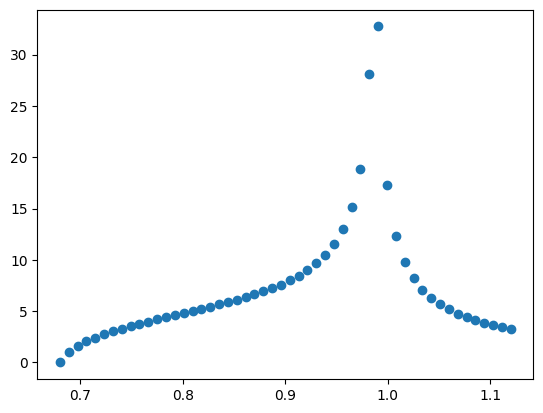

In [ ]:
import random

selected = random.choice(list(experiments.values()))
rand_params = selected["params"].sample(n=1).iloc[0]
print(rand_params)

xspace = np.linspace(lower_th, upper_th, max_bins)
rand_model = selected["model"]
I = rand_model(xspace, rand_params['c11'], rand_params['c12'], rand_params['c22'], rand_params.iloc[-2], rand_params.iloc[-1])
plt.scatter(xspace, I)